# 🏢 렌탈/통신 운영 의사결정 AI 에이전트
## Snowflake Hackathon 2026

### 문제 정의
렌탈/통신 업체의 **영업, 마케팅, CS** 부서는 각각 따로 데이터를 보고 의사결정한다.
- 마케팅: 비효율 채널에 예산 낭비
- 영업: 상담 유입 자체가 줄어듦
- CS: 고객 전화 절반이 연결 안됨

→ **세 부서의 악순환을 Snowflake Cortex로 끊는다**

### 데이터셋
| 데이터 | 활용 목적 |
|---|---|
| V01 지역별 계약 통계 | 영업 트렌드 + Cortex ML 예측 |
| V03 퍼널 전환율 | 병목 구간 탐지 |
| V07 GA4 채널 CVR | 마케팅 효율 분석 |
| V09 콜센터 통계 | CS 연결률 분석 |
| V10 시간대별 콜 분포 | CS 피크타임 탐지 |

### Cortex 활용
| Cortex 기능 | 역할 |
|---|---|
| **Cortex ML FORECAST** | 지역별 다음달 수요 예측 |
| **Cortex Analyst** | 자연어 → SQL 자동 변환 |
| **Cortex Complete** | 통합 인사이트 + 액션 추천 |

## 0. 환경 설정

In [2]:
from snowflake.snowpark import Session
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

warnings.filterwarnings('ignore')

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

# Snowflake 연결 (.env 기반)
connection_params = {
    "account": os.getenv("SNOWFLAKE_ACCOUNT", "SQHVTHB-UX70775"),
    "user": os.getenv("SNOWFLAKE_USER", "CGBrian"),
    "password": os.getenv("SNOWFLAKE_PASSWORD"),
    "warehouse": os.getenv("SNOWFLAKE_WAREHOUSE", "COMPUTE_WH"),
    "database": "SEOUL_DISTRICTLEVEL_DATA_FLOATING_POPULATION_CONSUMPTION_AND_ASSETS",
    "schema": "TELECOM_INSIGHTS"
}

session = Session.builder.configs(connection_params).create()

DB_AJD = "SOUTH_KOREA_TELECOM_SUBSCRIPTION_ANALYTICS__CONTRACTS_MARKETING_AND_CALL_CENTER_INSIGHTS_BY_REGION"

print("✅ Snowflake connection completed")

✅ Snowflake connection completed


## 1. 영업 트렌드 분석 (V01)
### 목적
- 서울 지역별 월별 계약 트렌드 파악
- 성장 패턴 및 계절성 확인
- Cortex ML FORECAST 예측을 위한 기반 데이터

In [3]:
df_v01 = session.sql(f"""
    SELECT 
        YEAR_MONTH,
        INSTALL_STATE,
        INSTALL_CITY,
        MAIN_CATEGORY_NAME,
        SUM(CONTRACT_COUNT) AS CONTRACTS,
        AVG(OPEN_CVR) AS OPEN_CVR,
        AVG(PAYEND_CVR) AS PAYEND_CVR,
        SUM(TOTAL_NET_SALES) AS REVENUE
    FROM {DB_AJD}.TELECOM_INSIGHTS.V01_MONTHLY_REGIONAL_CONTRACT_STATS
    WHERE INSTALL_STATE = '서울'
    AND YEAR_MONTH < '2026-04-01'
    GROUP BY YEAR_MONTH, INSTALL_STATE, INSTALL_CITY, MAIN_CATEGORY_NAME
    ORDER BY YEAR_MONTH, CONTRACTS DESC
""").to_pandas()

df_v01['YEAR_MONTH'] = pd.to_datetime(df_v01['YEAR_MONTH'])
print(f"데이터 크기: {df_v01.shape}")
print(f"기간: {df_v01['YEAR_MONTH'].min().strftime('%Y-%m')} ~ {df_v01['YEAR_MONTH'].max().strftime('%Y-%m')}")
print(f"카테고리: {df_v01['MAIN_CATEGORY_NAME'].unique()}")
df_v01.head()

데이터 크기: (3220, 8)
기간: 2023-03 ~ 2026-03
카테고리: ['인터넷' '렌탈' '알뜰 요금제' '유심만' '모바일' '다이렉트자보' '기업용인터넷']


,YEAR_MONTH,INSTALL_STATE,INSTALL_CITY,MAIN_CATEGORY_NAME,CONTRACTS,OPEN_CVR,PAYEND_CVR,REVENUE
0,2023-03-01,서울,송파구,인터넷,6,100.00,100.00,2235879
1,2023-03-01,서울,강남구,인터넷,6,100.00,100.00,959001
2,2023-04-01,서울,강남구,인터넷,6,66.67,83.33,2812762
3,2023-06-01,서울,관악구,인터넷,8,87.50,100.00,2694998
4,2023-06-01,서울,노원구,인터넷,6,100.00,100.00,1956500


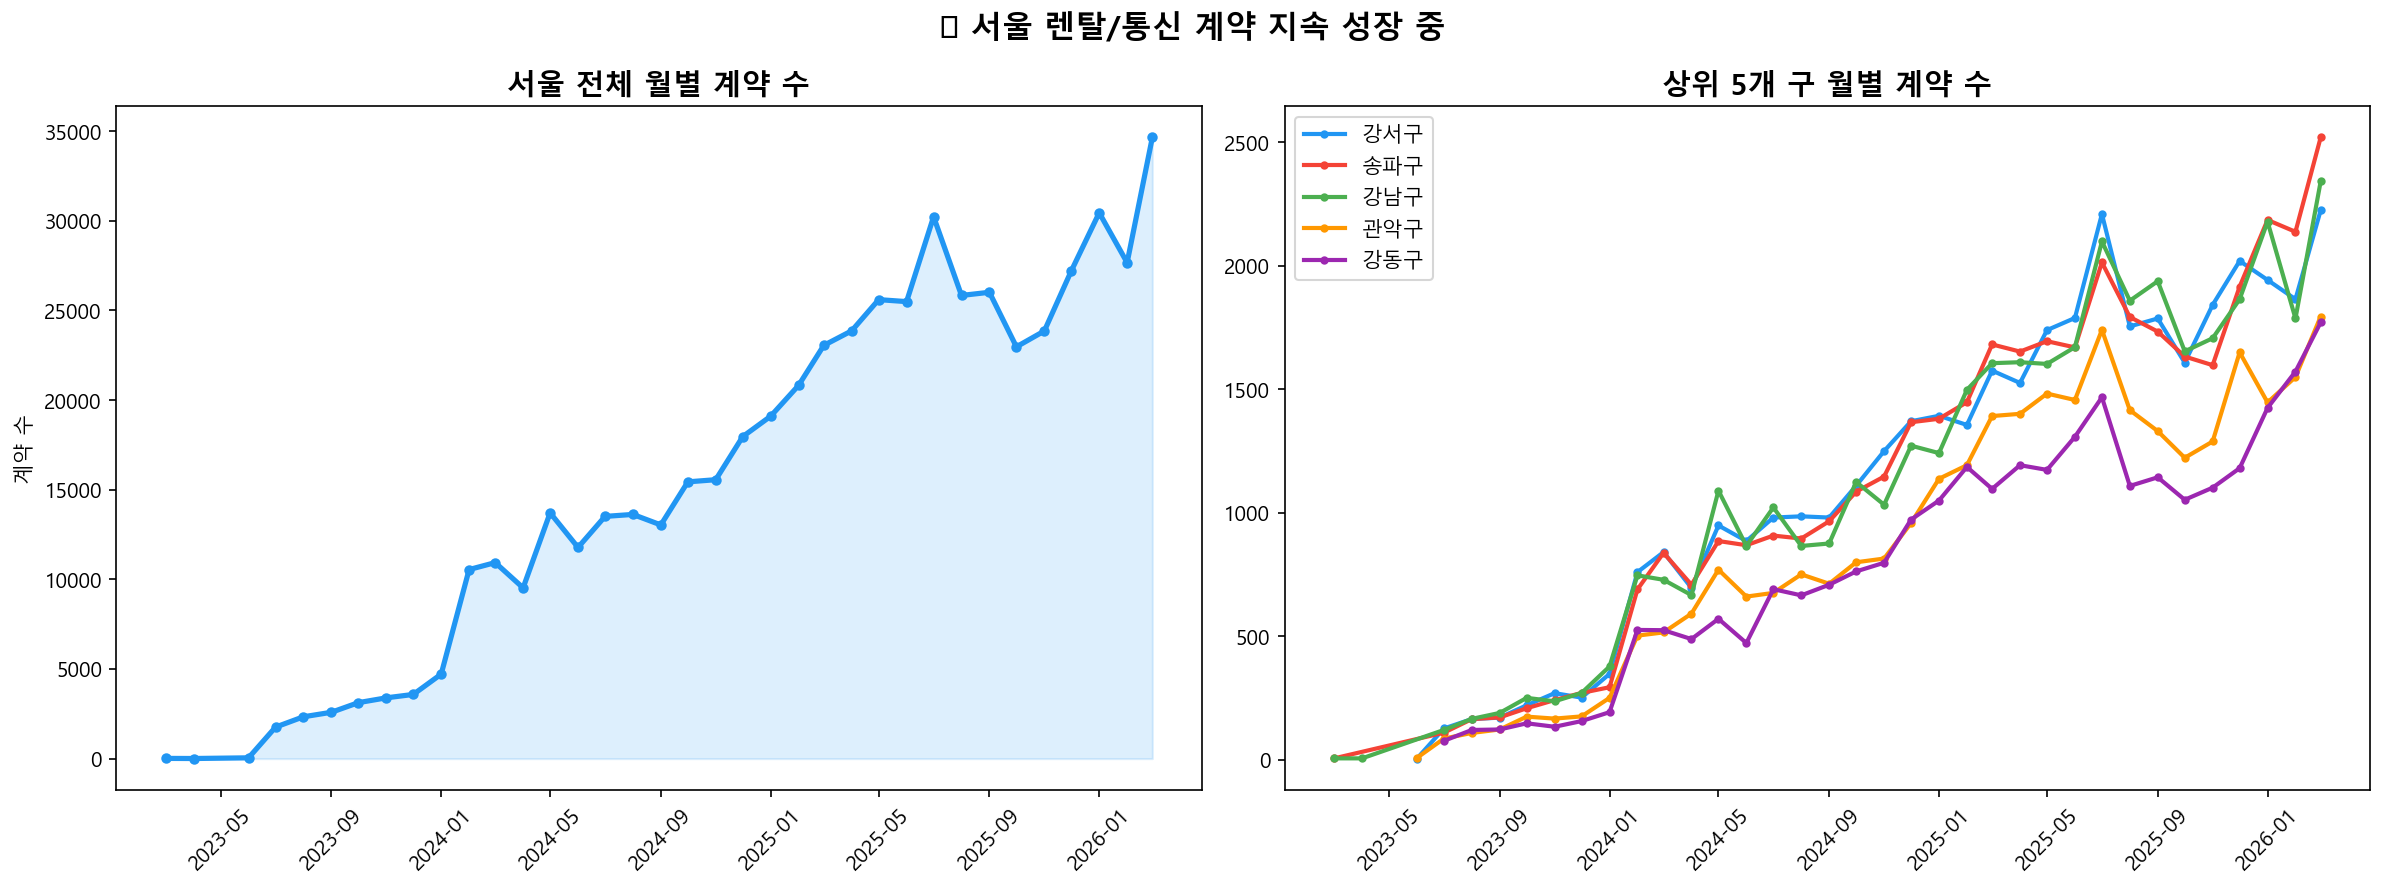

In [4]:
# 서울 전체 월별 계약 트렌드
df_total = df_v01.groupby('YEAR_MONTH').agg(
    CONTRACTS=('CONTRACTS', 'sum')
).reset_index()

# 상위 5개 구
top5 = df_v01.groupby('INSTALL_CITY')['CONTRACTS'].sum()\
    .sort_values(ascending=False).head(5).index.tolist()
df_city = df_v01[df_v01['INSTALL_CITY'].isin(top5)].groupby(
    ['YEAR_MONTH', 'INSTALL_CITY'])['CONTRACTS'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 전체 트렌드
axes[0].plot(df_total['YEAR_MONTH'], df_total['CONTRACTS'],
             color='#2196F3', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(df_total['YEAR_MONTH'], df_total['CONTRACTS'], alpha=0.15, color='#2196F3')
axes[0].set_title('서울 전체 월별 계약 수', fontsize=14, fontweight='bold')
axes[0].set_ylabel('계약 수')
axes[0].tick_params(axis='x', rotation=45)

# 상위 5개 구
colors5 = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']
for i, city in enumerate(top5):
    df_c = df_city[df_city['INSTALL_CITY'] == city]
    axes[1].plot(df_c['YEAR_MONTH'], df_c['CONTRACTS'],
                 marker='o', markersize=3, label=city, color=colors5[i], linewidth=2)

axes[1].set_title('상위 5개 구 월별 계약 수', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('📈 서울 렌탈/통신 계약 지속 성장 중', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('v01_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. 퍼널 전환율 분석 (V03)
### 목적
- 상담요청 → 청약 → 접수 → 개통 → 지급 단계별 이탈 파악
- **병목 구간 탐지** → CS 개입 포인트 도출
- 마케팅 채널 개선과 연결

In [5]:
df_v03 = session.sql(f"""
    SELECT *
    FROM {DB_AJD}.TELECOM_INSIGHTS.V03_CONTRACT_FUNNEL_CONVERSION
""").to_pandas()

df_v03['YEAR_MONTH'] = pd.to_datetime(df_v03['YEAR_MONTH'])

# 렌탈/인터넷 집중
df_funnel = df_v03[df_v03['MAIN_CATEGORY_NAME'].isin(['렌탈', '인터넷'])].copy()

# 평균 퍼널 CVR
funnel_avg = df_funnel.groupby('MAIN_CATEGORY_NAME')[
    ['CVR_CONSULT_REQUEST','CVR_REGISTEND','CVR_OPEN','CVR_PAYEND','OVERALL_CVR']
].mean().round(1)

print("=== 단계별 평균 CVR (%) ===")
print(funnel_avg.to_string())

=== 단계별 평균 CVR (%) ===
                    CVR_CONSULT_REQUEST  CVR_REGISTEND  CVR_OPEN  CVR_PAYEND  OVERALL_CVR
MAIN_CATEGORY_NAME                                                                       
렌탈                                 28.3           89.8      72.7       103.9         50.9
인터넷                                21.6           81.5      71.2       104.8         50.4


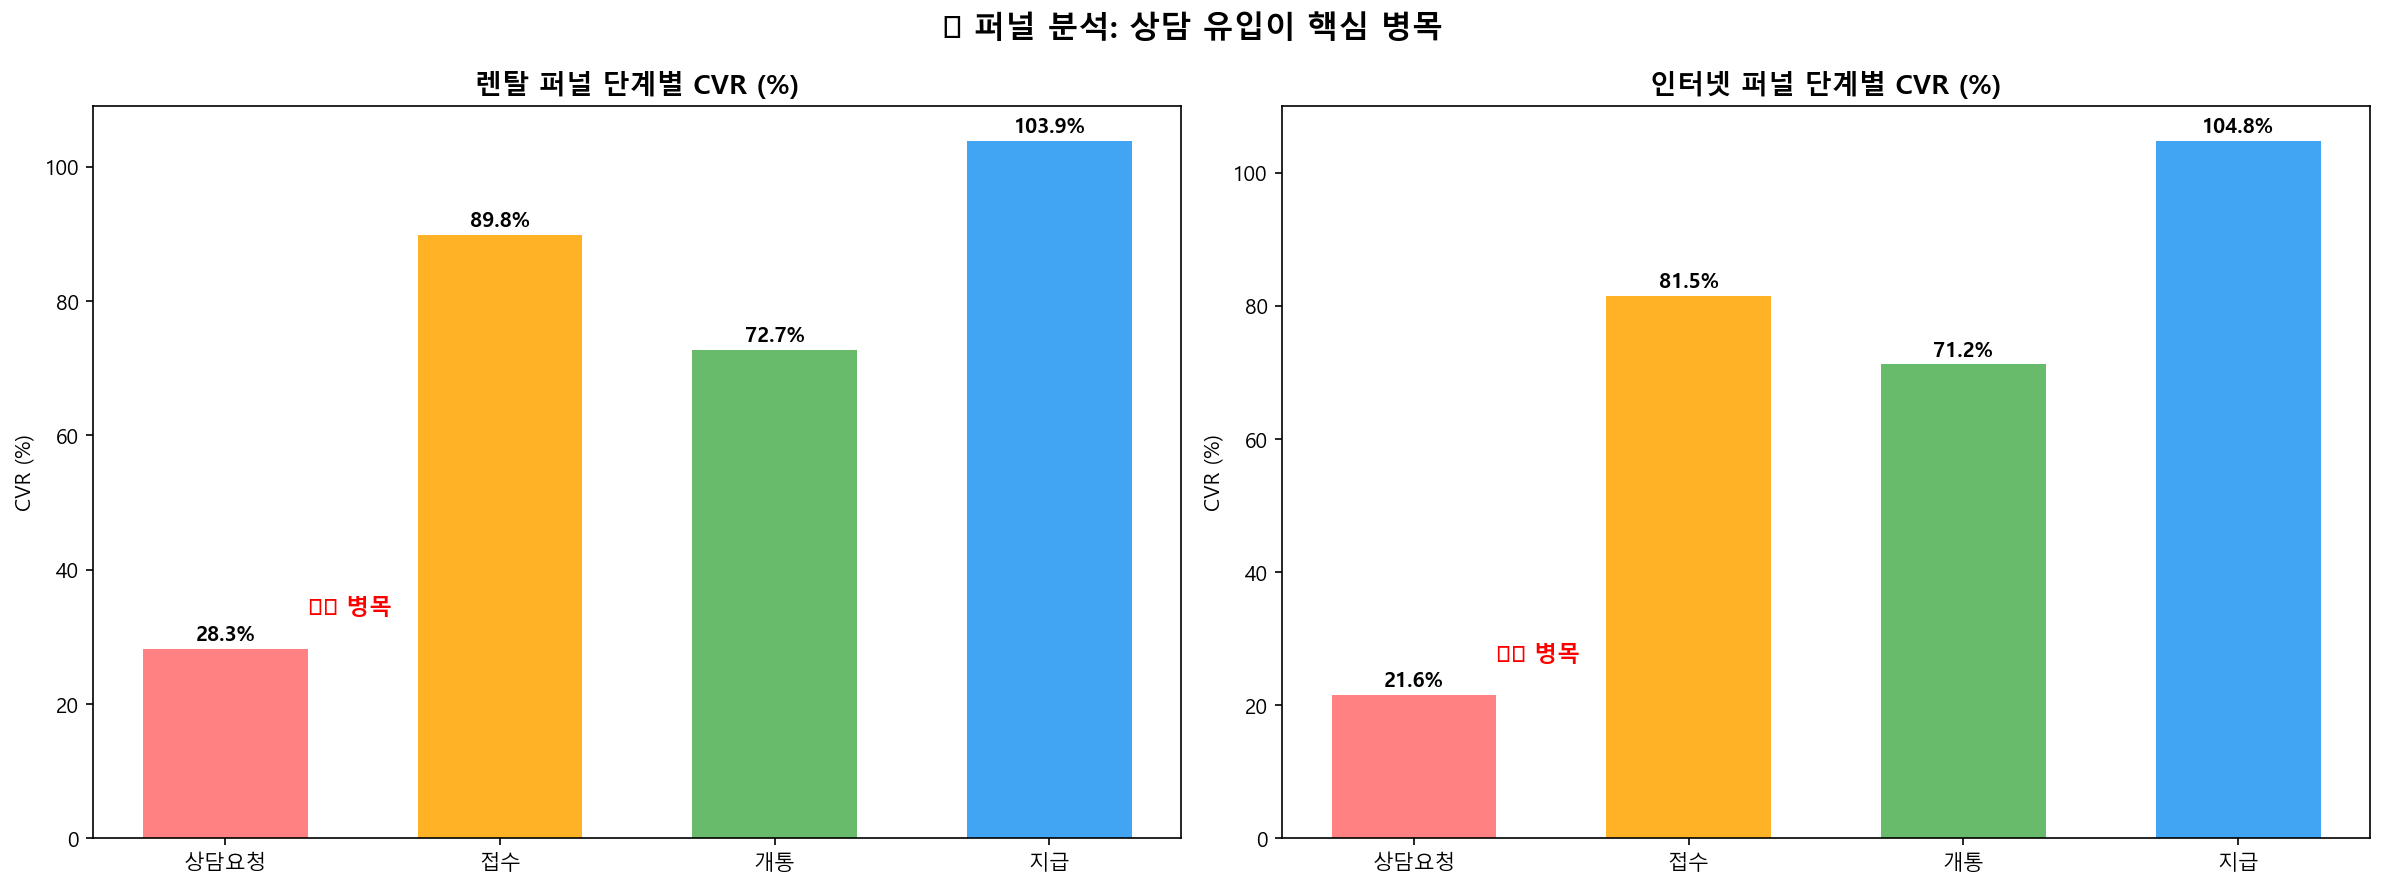


인사이트: 상담요청 CVR이 제일 낮음 → 마케팅 채널 최적화가 핵심


In [6]:
# 퍼널 시각화
categories = ['렌탈', '인터넷']
stages = ['상담요청', '접수', '개통', '지급']
cvr_cols = ['CVR_CONSULT_REQUEST', 'CVR_REGISTEND', 'CVR_OPEN', 'CVR_PAYEND']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_funnel = ['#FF6B6B', '#FFA500', '#4CAF50', '#2196F3']

for idx, cat in enumerate(categories):
    df_cat = df_v03[df_v03['MAIN_CATEGORY_NAME'] == cat][cvr_cols].mean()
    vals = df_cat.values

    bars = axes[idx].bar(stages, vals, color=colors_funnel, alpha=0.85, width=0.6)
    axes[idx].set_title(f'{cat} 퍼널 단계별 CVR (%)', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('CVR (%)')

    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + 0.5,
                       f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

    # 병목 표시
    min_idx = vals.argmin()
    axes[idx].annotate('⚠️ 병목',
                        xy=(min_idx, vals[min_idx]),
                        xytext=(min_idx + 0.3, vals[min_idx] + 5),
                        fontsize=11, color='red', fontweight='bold')

plt.suptitle('📊 퍼널 분석: 상담 유입이 핵심 병목', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('v03_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n인사이트: 상담요청 CVR이 제일 낮음 → 마케팅 채널 최적화가 핵심")

## 3. 마케팅 채널 효율 분석 (V07)
### 목적
- 채널별 CVR 비교 분석
- **핵심 발견: 동일 플랫폼 내 CVR 최대 4,000배 차이**
- 볼륨(세션수) 기준 예산 집행의 비효율성 증명

In [7]:
df_v07 = session.sql(f"""
    SELECT 
        UTM_SOURCE,
        UTM_MEDIUM,
        SUM(TOTAL_SESSIONS) AS TOTAL_SESSIONS,
        SUM(TOTAL_CONTRACTS) AS TOTAL_CONTRACTS,
        SUM(TOTAL_REVENUE) AS TOTAL_REVENUE,
        AVG(CONTRACT_CVR) AS AVG_CVR,
        SUM(TOTAL_REVENUE) / NULLIF(SUM(TOTAL_CONTRACTS), 0) AS REVENUE_PER_CONTRACT
    FROM {DB_AJD}.TELECOM_INSIGHTS.V07_GA4_MARKETING_ATTRIBUTION
    WHERE UTM_SOURCE != '(not set)'
    GROUP BY UTM_SOURCE, UTM_MEDIUM
    ORDER BY AVG_CVR DESC
""").to_pandas()

df_v07_valid = df_v07[df_v07['TOTAL_CONTRACTS'] >= 10].copy()
print(f"유효 채널 수: {len(df_v07_valid)}개")
df_v07_valid.head(10)

유효 채널 수: 431개


,UTM_SOURCE,UTM_MEDIUM,TOTAL_SESSIONS,TOTAL_CONTRACTS,TOTAL_REVENUE,AVG_CVR,REVENUE_PER_CONTRACT
1,release.bidding.nosearch.com,referral,53,12,754998,41.845000,62916.500000
2,kakao,keyword,185,58,10581296,32.955000,182436.137931
6,nc_money,direct_ps,872,236,30651037,28.840000,129877.275424
11,cm_outorder,ppompu,74,20,5288800,27.030000,264440.000000
13,ppomppu_capsule,community,93,31,3412625,26.520000,110084.677419
16,nb_influencer_it,아이작_ren,78,14,1208847,25.000000,86346.214286
17,kakao,sa_talkchannel,10025,2351,158990981,24.394286,67626.959166
18,nc_money,gumiproperty,42,11,235900,23.215000,21445.454545
20,yt_influencer_daily,예보링_250101_250228_branded_ljh,349,75,900910,22.220000,12012.133333
22,nb_influencer_it,잡동사니저장소,134,26,3074275,22.070000,118241.346154


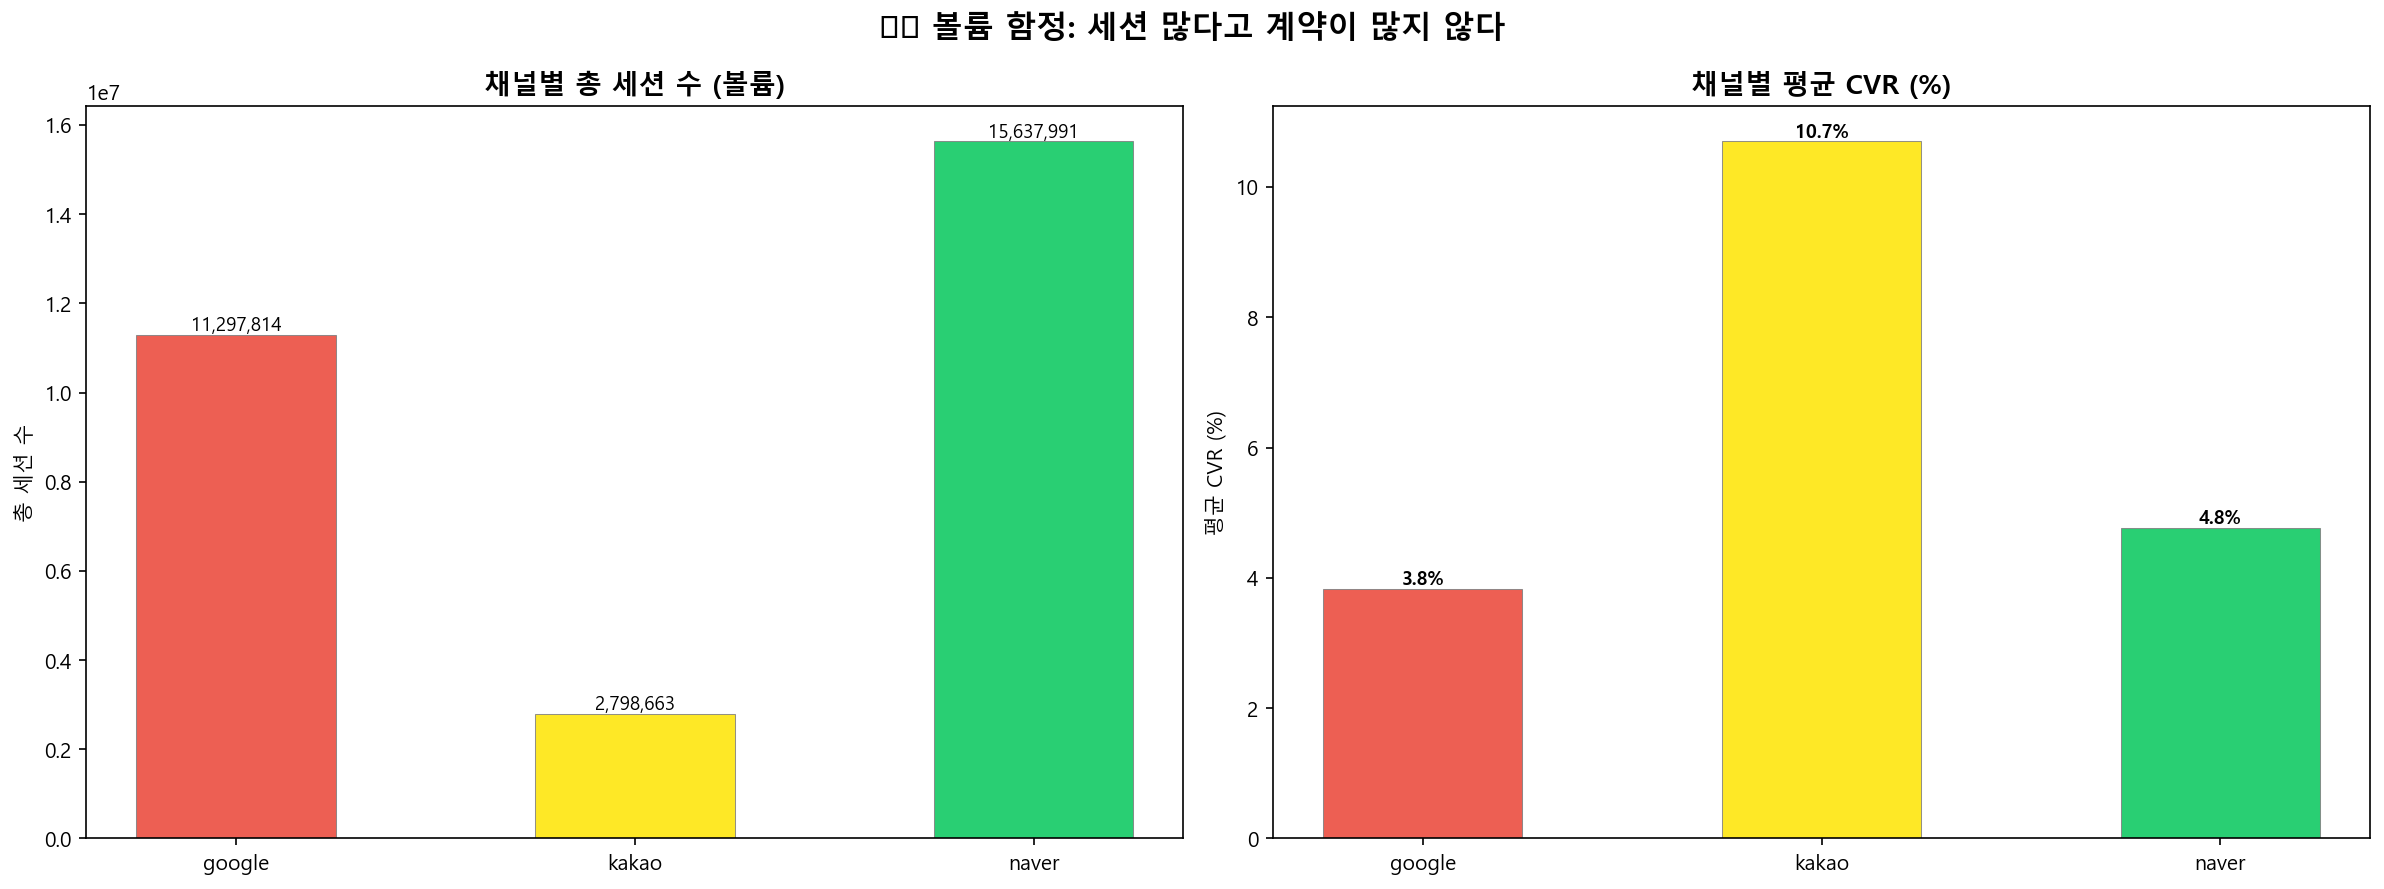

🔥 카카오 키워드 CVR: 33.0%
🔥 카카오 애드네트워크 CVR: 0.008%
🔥 동일 플랫폼 내 CVR 격차: 4119배!


In [8]:
# 볼륨 vs 효율 시각화
major = df_v07_valid[
    df_v07_valid['UTM_SOURCE'].isin(['naver', 'google', 'kakao'])
].groupby('UTM_SOURCE').agg(
    TOTAL_SESSIONS=('TOTAL_SESSIONS', 'sum'),
    TOTAL_CONTRACTS=('TOTAL_CONTRACTS', 'sum'),
    AVG_CVR=('AVG_CVR', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ch_colors = {'naver': '#03C75A', 'google': '#EA4335', 'kakao': '#FEE500'}
bar_colors = [ch_colors[s] for s in major['UTM_SOURCE']]

bars1 = axes[0].bar(major['UTM_SOURCE'], major['TOTAL_SESSIONS'],
                    color=bar_colors, alpha=0.85, width=0.5,
                    edgecolor='gray', linewidth=0.5)
axes[0].set_title('채널별 총 세션 수 (볼륨)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('총 세션 수')
for bar, val in zip(bars1, major['TOTAL_SESSIONS']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height(),
                 f'{int(val):,}', ha='center', va='bottom', fontsize=9)

bars2 = axes[1].bar(major['UTM_SOURCE'], major['AVG_CVR'],
                    color=bar_colors, alpha=0.85, width=0.5,
                    edgecolor='gray', linewidth=0.5)
axes[1].set_title('채널별 평균 CVR (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('평균 CVR (%)')
for bar, val in zip(bars2, major['AVG_CVR']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height(),
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('⚠️ 볼륨 함정: 세션 많다고 계약이 많지 않다', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('v07_volume_trap.png', dpi=150, bbox_inches='tight')
plt.show()

# 핵심 수치
kakao_kw = df_v07_valid[
    (df_v07_valid['UTM_SOURCE']=='kakao') &
    (df_v07_valid['UTM_MEDIUM']=='keyword')
]['AVG_CVR'].values[0]

kakao_ad = df_v07_valid[
    (df_v07_valid['UTM_SOURCE']=='kakao') &
    (df_v07_valid['UTM_MEDIUM']=='adnetwork')
]['AVG_CVR'].values[0]

print(f"🔥 카카오 키워드 CVR: {kakao_kw:.1f}%")
print(f"🔥 카카오 애드네트워크 CVR: {kakao_ad:.3f}%")
print(f"🔥 동일 플랫폼 내 CVR 격차: {kakao_kw/kakao_ad:.0f}배!")

## 3-2. CVR vs Revenue: Rule Engine이 필요한 이유

> CVR이 높은 채널이 반드시 매출 기여도가 높은 것은 아니다.
> → CVR과 Revenue를 함께 고려한 **복합 scoring**이 필요하다.


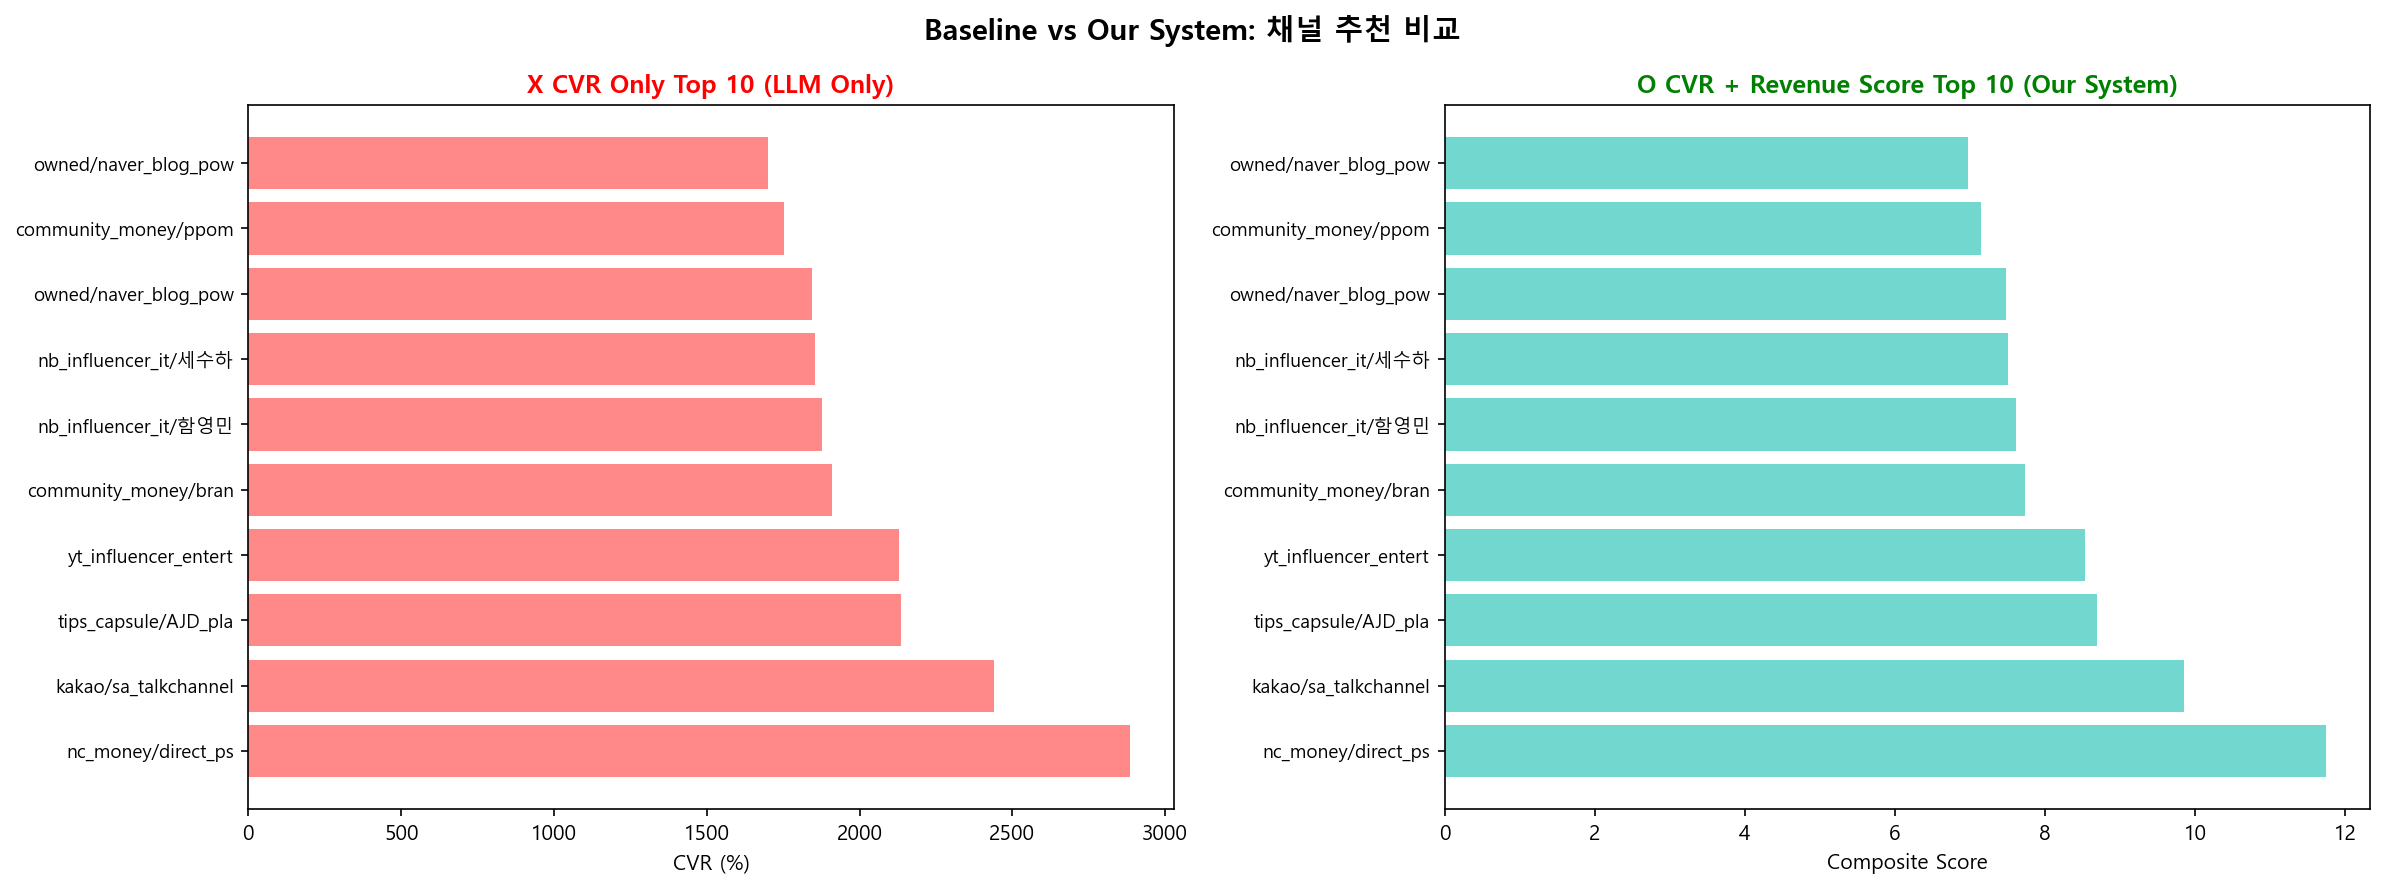

CVR Only Top1: nc_money / direct_ps CVR=2884.0%
Score Top1: nc_money / direct_ps CVR=2884.0%
-> 두 방식의 Top1이 다르면 Rule Engine 필요성 입증


In [ ]:
import os
os.makedirs("assets", exist_ok=True)

# 유효 채널 필터
df_scored = df_v07_valid[
    (df_v07_valid["TOTAL_SESSIONS"] >= 500) &
    (df_v07_valid["TOTAL_CONTRACTS"] >= 50)
].copy()
df_scored["REV_PER_SESSION"] = df_scored["TOTAL_REVENUE"] / df_scored["TOTAL_SESSIONS"]
df_scored["SCORE"] = df_scored["AVG_CVR"] * 0.4 + (df_scored["REV_PER_SESSION"] / 100_000) * 0.6

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LLM Only (CVR만)
top_cvr = df_v07_valid.nlargest(10, "AVG_CVR")
labels_cvr = [f"{s}/{m}"[:20] for s,m in zip(top_cvr["UTM_SOURCE"], top_cvr["UTM_MEDIUM"])]
axes[0].barh(range(len(top_cvr)), top_cvr["AVG_CVR"] * 100, color="#FF6B6B", alpha=0.8)
axes[0].set_yticks(range(len(top_cvr)))
axes[0].set_yticklabels(labels_cvr, fontsize=9)
axes[0].set_title("X CVR Only Top 10 (LLM Only)", fontsize=12, fontweight="bold", color="red")
axes[0].set_xlabel("CVR (%)")

# Our System (CVR + Revenue)
top_score = df_scored.nlargest(10, "SCORE")
labels_score = [f"{s}/{m}"[:20] for s,m in zip(top_score["UTM_SOURCE"], top_score["UTM_MEDIUM"])]
axes[1].barh(range(len(top_score)), top_score["SCORE"], color="#4ECDC4", alpha=0.8)
axes[1].set_yticks(range(len(top_score)))
axes[1].set_yticklabels(labels_score, fontsize=9)
axes[1].set_title("O CVR + Revenue Score Top 10 (Our System)", fontsize=12, fontweight="bold", color="green")
axes[1].set_xlabel("Composite Score")

plt.suptitle("Baseline vs Our System: 채널 추천 비교", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("assets/baseline_vs_ours.png", dpi=150, bbox_inches="tight")
plt.show()

print("CVR Only Top1:", top_cvr.iloc[0]["UTM_SOURCE"], "/", top_cvr.iloc[0]["UTM_MEDIUM"],
      f"CVR={top_cvr.iloc[0]['AVG_CVR']*100:.1f}%")
print("Score Top1:", top_score.iloc[0]["UTM_SOURCE"], "/", top_score.iloc[0]["UTM_MEDIUM"],
      f"CVR={top_score.iloc[0]['AVG_CVR']*100:.1f}%")
print("-> 두 방식의 Top1이 다르면 Rule Engine 필요성 입증")


## 3-3. Threshold 설정 근거 (sessions >= 500, contracts >= 50)

> 소규모 채널은 CVR이 통계적으로 불안정 → 최소 트래픽 필터 필요


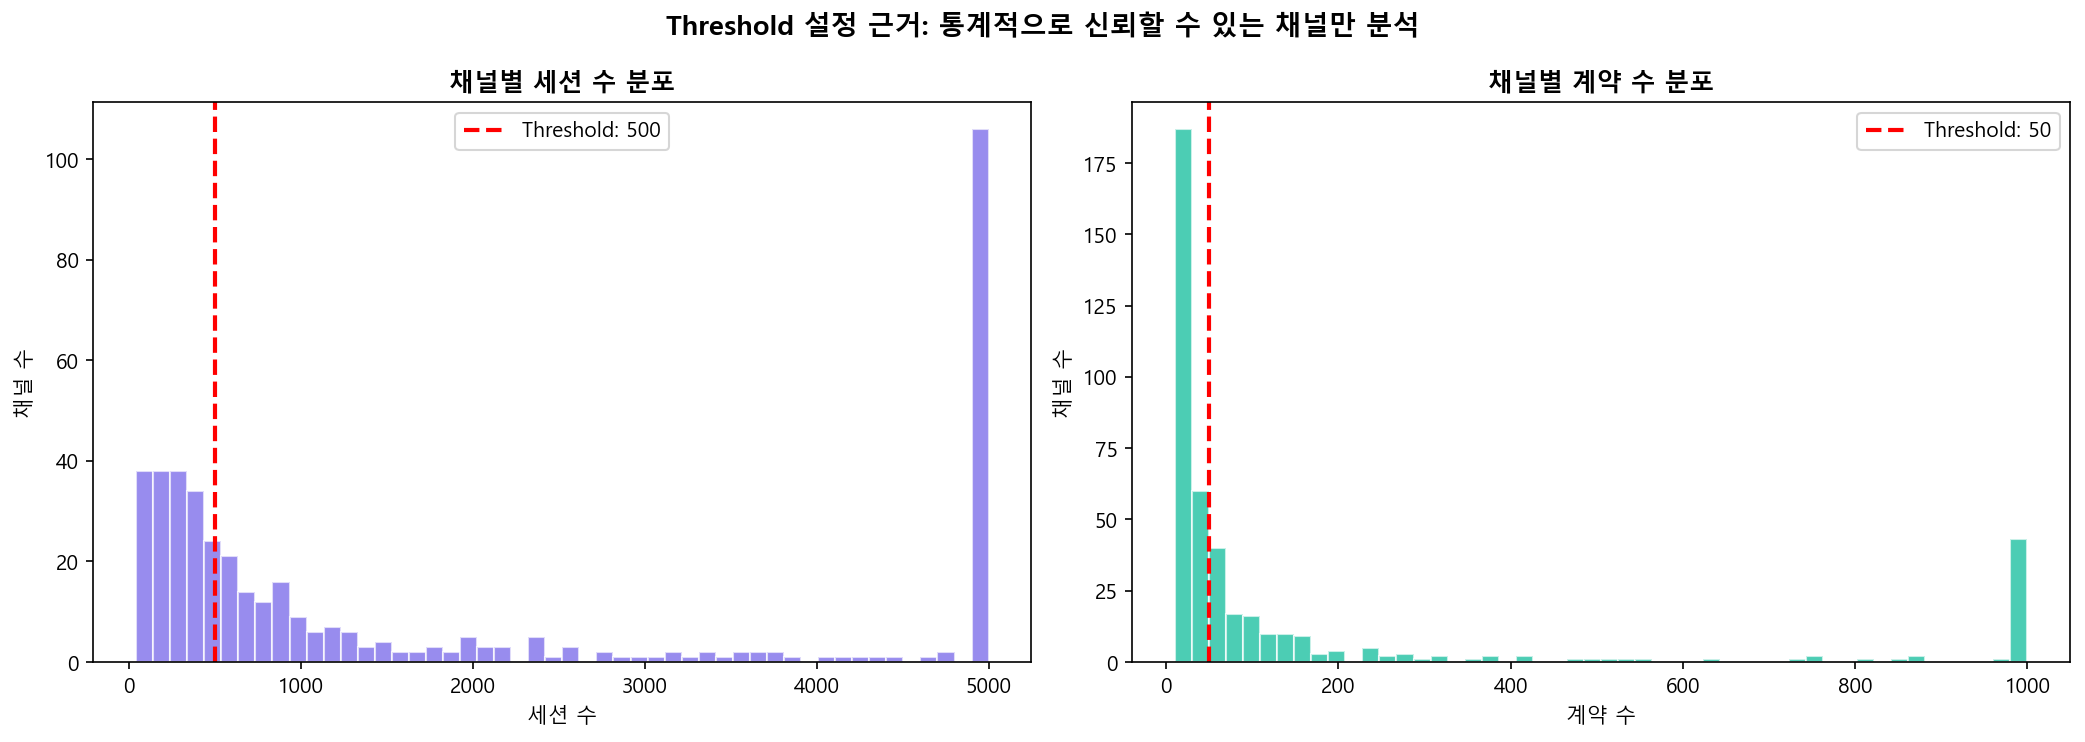

전체 유효 채널: 431개
Threshold 통과 채널: 172개
-> 통계적으로 신뢰할 수 있는 172개 채널로 분석 범위 한정


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_v07_valid["TOTAL_SESSIONS"].clip(upper=5000), bins=50,
             color="#6C5CE7", alpha=0.7, edgecolor="white")
axes[0].axvline(x=500, color="red", linewidth=2, linestyle="--", label="Threshold: 500")
axes[0].set_title("채널별 세션 수 분포", fontsize=12, fontweight="bold")
axes[0].set_xlabel("세션 수")
axes[0].set_ylabel("채널 수")
axes[0].legend()

axes[1].hist(df_v07_valid["TOTAL_CONTRACTS"].clip(upper=1000), bins=50,
             color="#00B894", alpha=0.7, edgecolor="white")
axes[1].axvline(x=50, color="red", linewidth=2, linestyle="--", label="Threshold: 50")
axes[1].set_title("채널별 계약 수 분포", fontsize=12, fontweight="bold")
axes[1].set_xlabel("계약 수")
axes[1].set_ylabel("채널 수")
axes[1].legend()

plt.suptitle("Threshold 설정 근거: 통계적으로 신뢰할 수 있는 채널만 분석", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

total = len(df_v07_valid)
filtered = len(df_scored)
print(f"전체 유효 채널: {total}개")
print(f"Threshold 통과 채널: {filtered}개")
print(f"-> 통계적으로 신뢰할 수 있는 {filtered}개 채널로 분석 범위 한정")


## 6. EDA 결론 및 Rule Engine 설계 근거

### 발견된 문제
1. **마케팅**: 채널별 CVR 최대 4,000배 격차 → 예산 재배분 필요
2. **퍼널**: 접수->개통 단계 최대 이탈 → 프로세스 개선 필요
3. **CS**: 수신 연결률 ~50%, 목표 70% 미달 → 인력 배치 최적화 필요

### Rule Engine 설계 근거
| 문제 | 단순 LLM 접근 | Rule Engine 접근 |
|------|-------------|----------------|
| 채널 추천 | CVR 높은 채널 선택 | CVR 40% + Revenue 60% 복합 score |
| 소규모 채널 | 포함 (오류 위험) | sessions>=500, contracts>=50 필터 |
| 비교 기준 | 절대값 | 전체 평균 대비 순위 |

### 결론
```
CVR만 보면 틀린다
  -> Revenue 함께 고려 필요
    -> Threshold로 통계적 신뢰성 확보
      -> CVR + Revenue 복합 scoring 설계
        -> Cortex AI 에이전트로 자동화
```

> EDA = "왜 이 시스템을 만들었는지"에 대한 데이터 근거


## 4. 콜센터 패턴 분석 (V09 / V10)
### 목적
- 월별 연결률 파악 → **절반이 연결 안됨** 발견
- 시간대/요일별 피크타임 탐지
- CS 인력 배치 최적화 포인트 도출

In [14]:
df_v09 = session.sql(f"""
    SELECT *
    FROM {DB_AJD}.TELECOM_INSIGHTS.V09_MONTHLY_CALL_STATS
""").to_pandas()

df_v09['YEAR_MONTH'] = pd.to_datetime(df_v09['YEAR_MONTH'])
df_inbound = df_v09[df_v09['DIVISION_NAME'] == '수신'].copy()

# 카테고리별 평균 연결률
conn_rate = df_inbound.groupby('MAIN_CATEGORY_NAME').agg(
    AVG_CONNECTION_RATE=('CONNECTION_RATE', 'mean'),
    TOTAL_CALLS=('CALL_COUNT', 'sum'),
    UNCONNECTED=('UNCONNECTED_COUNT', 'sum')
).round(1).sort_values('AVG_CONNECTION_RATE')

print("=== 수신 카테고리별 평균 연결률 ===")
print(conn_rate.to_string())

avg_conn = df_inbound['CONNECTION_RATE'].mean()
print(f"\n🔥 전체 수신 평균 연결률: {avg_conn:.1f}% → {100-avg_conn:.1f}%가 연결 안됨!")

=== 수신 카테고리별 평균 연결률 ===
                    AVG_CONNECTION_RATE  TOTAL_CALLS  UNCONNECTED
MAIN_CATEGORY_NAME                                               
이사                                 29.5           92           67
다이렉트자보                             36.7         1902         1158
부동산                                40.9          101           59
알뜰 요금제                             46.8        52837        27926
모바일                                47.5       259621       131868
유심만                                48.2       313833       133046
인터넷                                49.8      1995446       792011
렌탈                                 52.0       784105       328392
상조                                 54.0          152           75
기업용인터넷                             66.5        21440         8165

🔥 전체 수신 평균 연결률: 50.2% → 49.8%가 연결 안됨!


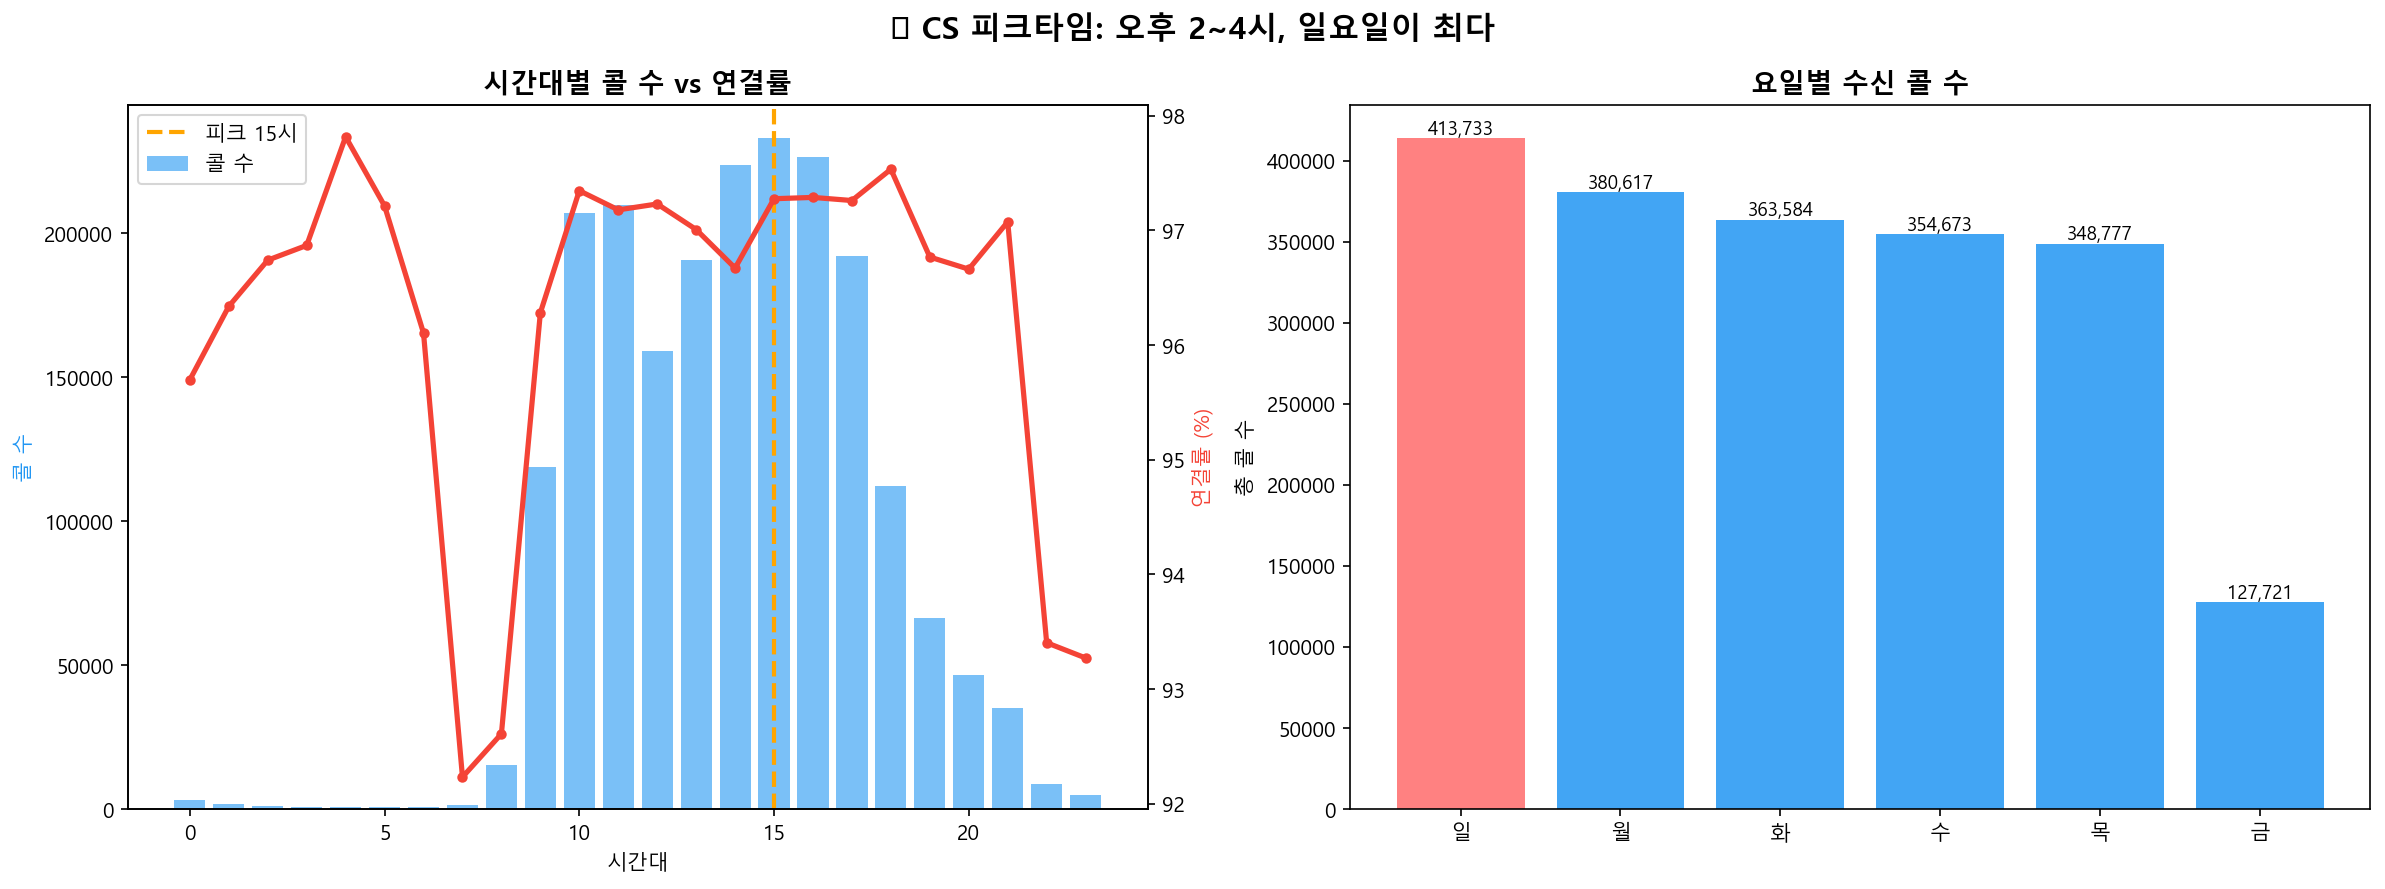

In [15]:
df_v10 = session.sql(f"""
    SELECT *
    FROM {DB_AJD}.TELECOM_INSIGHTS.V10_HOURLY_CALL_DISTRIBUTION
""").to_pandas()

df_inbound_10 = df_v10[df_v10['DIVISION_NAME'] == '수신'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 시간대별
hourly = df_inbound_10.groupby('HOUR_OF_DAY').agg(
    CALL_COUNT=('CALL_COUNT', 'sum'),
    CONNECTION_RATE=('CONNECTION_RATE', 'mean')
).reset_index()

ax1 = axes[0]
ax2 = ax1.twinx()
ax1.bar(hourly['HOUR_OF_DAY'], hourly['CALL_COUNT'], color='#2196F3', alpha=0.6, label='콜 수')
ax2.plot(hourly['HOUR_OF_DAY'], hourly['CONNECTION_RATE'],
         color='#F44336', linewidth=2.5, marker='o', markersize=4, label='연결률')
ax1.set_title('시간대별 콜 수 vs 연결률', fontsize=13, fontweight='bold')
ax1.set_xlabel('시간대')
ax1.set_ylabel('콜 수', color='#2196F3')
ax2.set_ylabel('연결률 (%)', color='#F44336')
peak_hour = hourly.loc[hourly['CALL_COUNT'].idxmax(), 'HOUR_OF_DAY']
ax1.axvline(x=peak_hour, color='orange', linestyle='--', linewidth=2, label=f'피크 {peak_hour}시')
ax1.legend(loc='upper left')

# 요일별
daily = df_inbound_10.groupby('DAY_OF_WEEK_NAME').agg(
    CALL_COUNT=('CALL_COUNT', 'sum')
).reset_index()
day_order = ['일', '월', '화', '수', '목', '금']
daily['DAY_OF_WEEK_NAME'] = pd.Categorical(daily['DAY_OF_WEEK_NAME'], categories=day_order, ordered=True)
daily = daily.sort_values('DAY_OF_WEEK_NAME')
bar_colors_day = ['#FF6B6B' if d == '일' else '#2196F3' for d in daily['DAY_OF_WEEK_NAME']]
bars2 = axes[1].bar(daily['DAY_OF_WEEK_NAME'], daily['CALL_COUNT'], color=bar_colors_day, alpha=0.85)
axes[1].set_title('요일별 수신 콜 수', fontsize=13, fontweight='bold')
axes[1].set_ylabel('총 콜 수')
for bar, val in zip(bars2, daily['CALL_COUNT']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height(), f'{int(val):,}', ha='center', va='bottom', fontsize=9)

plt.suptitle('📞 CS 피크타임: 오후 2~4시, 일요일이 최다', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('v10_peak.png', dpi=150, bbox_inches='tight')
plt.show()

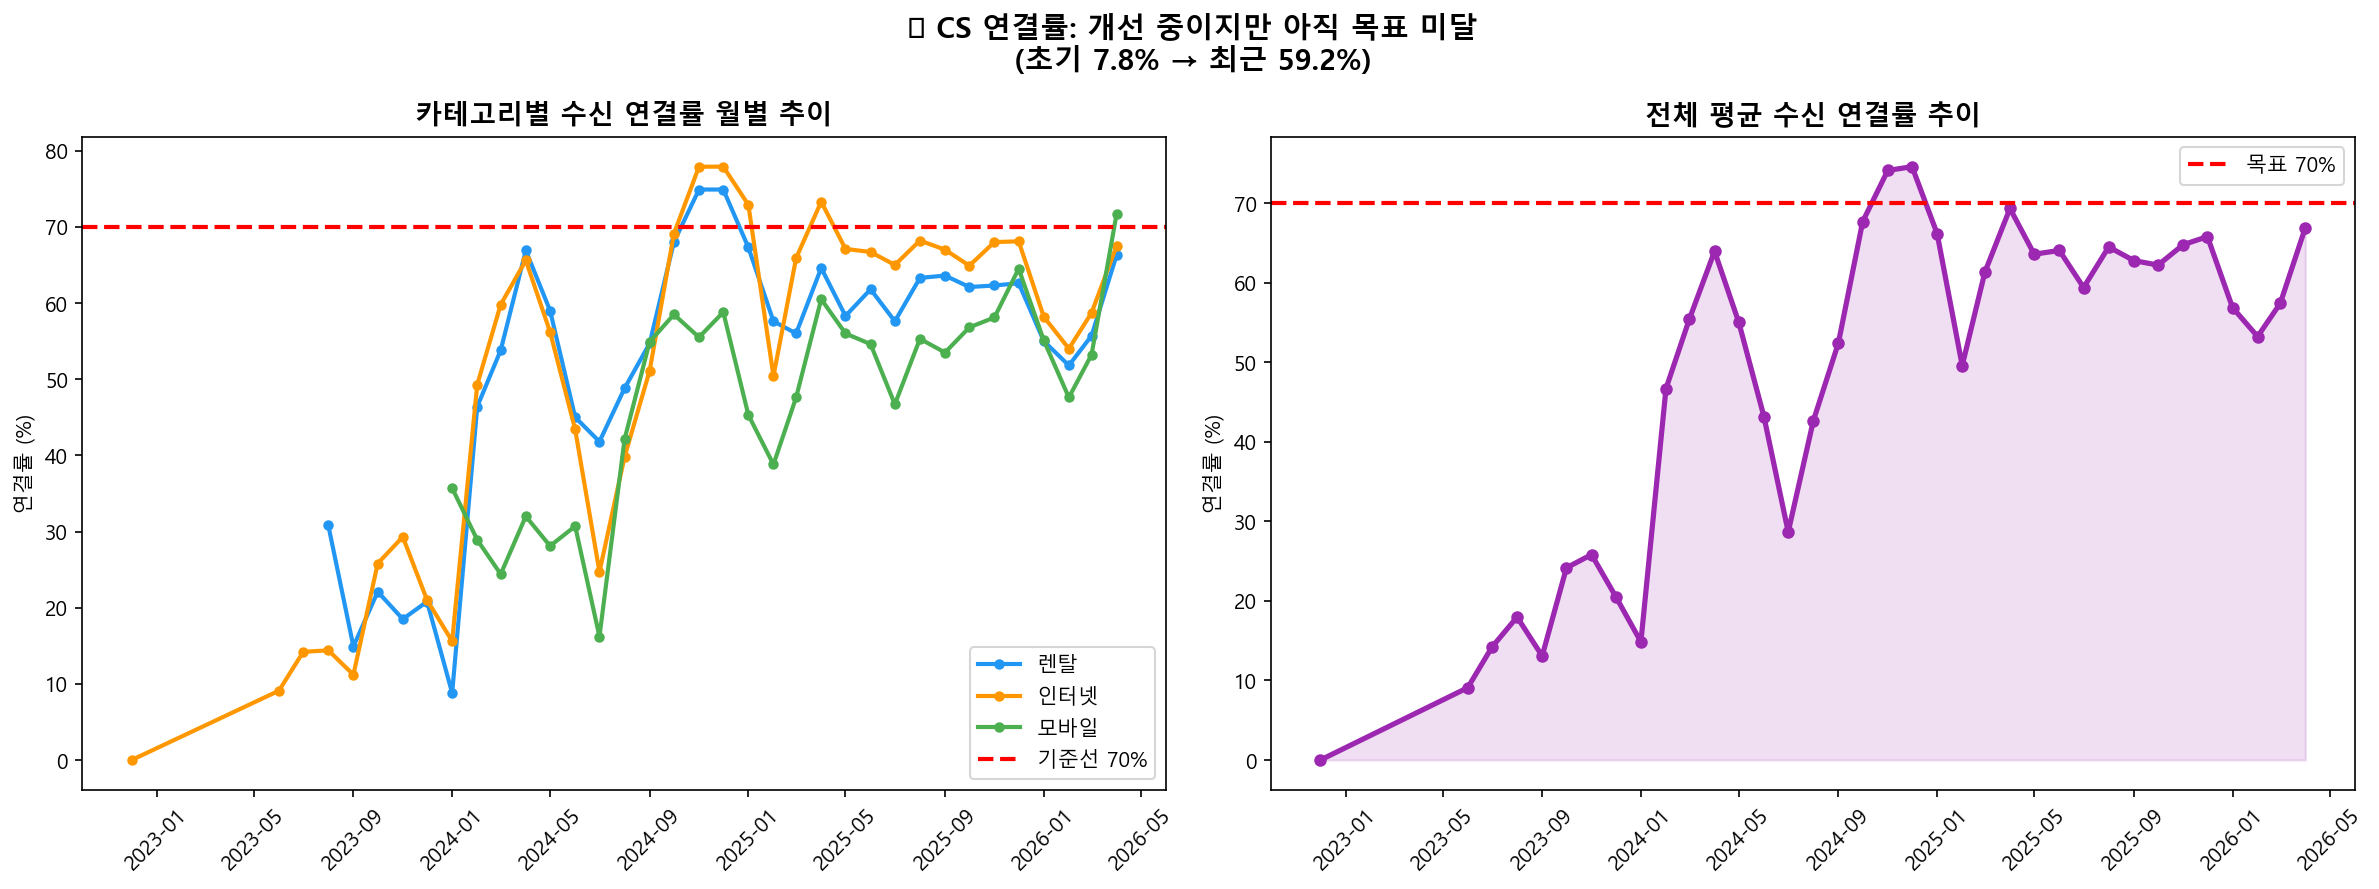


🔥 초기 평균 연결률: 7.8%
🔥 최근 평균 연결률: 59.2%
🔥 개선폭: +51.4%p
🔥 목표(70%) 대비 10.8%p 부족


In [16]:
# 월별 집계 + 정렬 제대로 해서 다시
df_v09_in = df_v09[df_v09['DIVISION_NAME'] == '수신'].copy()
df_v09_in['YEAR_MONTH'] = pd.to_datetime(df_v09_in['YEAR_MONTH'])

# 카테고리별 월별 집계 (혹시 중복 있을 경우 대비)
df_v09_grouped = df_v09_in.groupby(['YEAR_MONTH', 'MAIN_CATEGORY_NAME']).agg(
    CONNECTED=('CONNECTED_COUNT', 'sum'),
    UNCONNECTED=('UNCONNECTED_COUNT', 'sum'),
    TOTAL_CALLS=('CALL_COUNT', 'sum')
).reset_index()

# 연결률 재계산
df_v09_grouped['CONNECTION_RATE'] = (
    df_v09_grouped['CONNECTED'] / 
    (df_v09_grouped['CONNECTED'] + df_v09_grouped['UNCONNECTED']) * 100
).round(1)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cat, color in zip(['렌탈', '인터넷', '모바일'],
                      ['#2196F3', '#FF9800', '#4CAF50']):
    df_cat = df_v09_grouped[
        df_v09_grouped['MAIN_CATEGORY_NAME'] == cat
    ].sort_values('YEAR_MONTH')
    
    axes[0].plot(df_cat['YEAR_MONTH'], df_cat['CONNECTION_RATE'],
                 marker='o', label=cat, color=color, 
                 linewidth=2, markersize=4)

axes[0].axhline(y=70, color='red', linestyle='--', linewidth=2, label='기준선 70%')
axes[0].set_title('카테고리별 수신 연결률 월별 추이', fontsize=13, fontweight='bold')
axes[0].set_ylabel('연결률 (%)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# 전체 평균
df_avg = df_v09_grouped.groupby('YEAR_MONTH').apply(
    lambda x: (x['CONNECTED'].sum() / 
               (x['CONNECTED'].sum() + x['UNCONNECTED'].sum()) * 100)
).reset_index()
df_avg.columns = ['YEAR_MONTH', 'CONNECTION_RATE']
df_avg = df_avg.sort_values('YEAR_MONTH')

axes[1].plot(df_avg['YEAR_MONTH'], df_avg['CONNECTION_RATE'],
             color='#9C27B0', linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(df_avg['YEAR_MONTH'], df_avg['CONNECTION_RATE'],
                     alpha=0.15, color='#9C27B0')
axes[1].axhline(y=70, color='red', linestyle='--', linewidth=2, label='목표 70%')
axes[1].set_title('전체 평균 수신 연결률 추이', fontsize=13, fontweight='bold')
axes[1].set_ylabel('연결률 (%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

first_avg = df_avg.head(3)['CONNECTION_RATE'].mean()
last_avg = df_avg.tail(3)['CONNECTION_RATE'].mean()

plt.suptitle(f'📞 CS 연결률: 개선 중이지만 아직 목표 미달\n'
             f'(초기 {first_avg:.1f}% → 최근 {last_avg:.1f}%)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('v09_connection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🔥 초기 평균 연결률: {first_avg:.1f}%")
print(f"🔥 최근 평균 연결률: {last_avg:.1f}%")
print(f"🔥 개선폭: +{last_avg-first_avg:.1f}%p")
print(f"🔥 목표(70%) 대비 {70-last_avg:.1f}%p 부족")

## 5. 핵심 인사이트 종합

### 🔍 인사이트 1: 마케팅 채널 CVR 4,000배 격차
| 채널 | 세션 수 | CVR |
|---|---|---|
| 카카오 키워드 | 185 | **32.9%** |
| 카카오 애드네트워크 | 2,611,894 | **0.008%** |

→ 볼륨 기준 예산 집행 = 효율 낭비

### 🔍 인사이트 2: 퍼널 병목은 상담 유입
- 렌탈 상담요청 CVR: **28.7%**
- 인터넷 상담요청 CVR: **22.0%**

→ 마케팅 채널 최적화로 직접 해결 가능

### 🔍 인사이트 3: CS 연결률 절반 미만
- 수신 평균 연결률: **~50%**
- 피크타임: 오후 2~4시, **일요일 최다**

→ 평일 기준 인력 배치로 주말 수요 미대응

### 💡 세 부서의 악순환
```
잘못된 채널에 예산 낭비 (마케팅)
    → 상담 유입 감소 (퍼널)
        → 고객 전화 연결 안됨 (CS)
            → 계약 손실
```

### 🚀 Cortex 에이전트로 해결
> **Cortex ML**: 지역별 수요 예측  
> **Cortex Analyst**: 채널/퍼널/CS 데이터 통합 조회  
> **Cortex Complete**: 세 부서 동시 최적화 액션 추천

In [20]:
# 발표용 핵심 수치 최종 확정
print("=" * 60)
print("📊 발표용 핵심 수치")
print("=" * 60)

# 인사이트 1
kakao_kw = df_v07_valid[
    (df_v07_valid['UTM_SOURCE']=='kakao') &
    (df_v07_valid['UTM_MEDIUM']=='keyword')
]['AVG_CVR'].values[0]
kakao_ad = df_v07_valid[
    (df_v07_valid['UTM_SOURCE']=='kakao') &
    (df_v07_valid['UTM_MEDIUM']=='adnetwork')
]['AVG_CVR'].values[0]

print(f"\n[인사이트 1] 마케팅 채널 CVR 격차")
print(f"  카카오 키워드 CVR:        {kakao_kw:.1f}%")
print(f"  카카오 애드네트워크 CVR:   {kakao_ad:.3f}%")
print(f"  격차:                    {kakao_kw/kakao_ad:.0f}배")

# 인사이트 2
rental_consult = df_v03[df_v03['MAIN_CATEGORY_NAME']=='렌탈']['CVR_CONSULT_REQUEST'].mean()
internet_consult = df_v03[df_v03['MAIN_CATEGORY_NAME']=='인터넷']['CVR_CONSULT_REQUEST'].mean()
print(f"\n[인사이트 2] 퍼널 병목 - 상담 유입")
print(f"  렌탈 상담요청 CVR:    {rental_consult:.1f}%")
print(f"  인터넷 상담요청 CVR:  {internet_consult:.1f}%")

# 인사이트 3
avg_conn_rate = df_v09[df_v09['DIVISION_NAME']=='수신']['CONNECTION_RATE'].mean()
print(f"\n[인사이트 3] CS 연결률")
print(f"  수신 평균 연결률: {avg_conn_rate:.1f}%")
print(f"  미연결 비율:      {100-avg_conn_rate:.1f}%")
print(f"  피크 시간대:      오후 14~16시")
print(f"  최다 요일:        일요일")
print("=" * 60)


📊 발표용 핵심 수치

[인사이트 1] 마케팅 채널 CVR 격차
  카카오 키워드 CVR:        33.0%
  카카오 애드네트워크 CVR:   0.008%
  격차:                    4119배

[인사이트 2] 퍼널 병목 - 상담 유입
  렌탈 상담요청 CVR:    28.3%
  인터넷 상담요청 CVR:  21.6%

[인사이트 3] CS 연결률
  수신 평균 연결률: 50.2%
  미연결 비율:      49.8%
  피크 시간대:      오후 14~16시
  최다 요일:        일요일
